# Day 28: CNN Architecture - CIFAR-10 Image Classification
# 
# **Week 6, Day 28** | CNN Architecture, Convolutional Layers, Pooling & Image Classification Pipeline
# 


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import urllib.request
import tarfile
import sys
import datetime

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Create output directories
os.makedirs('outputs/models', exist_ok=True)
os.makedirs('outputs/plots', exist_ok=True)
os.makedirs('outputs/logs', exist_ok=True)

print(f"TensorFlow version: {tf.__version__}")


TensorFlow version: 2.21.0


# 2. Load CIFAR-10 with Fallback Methods

In [4]:
def load_cifar10_manual():
    """
    Load CIFAR-10 with multiple fallback methods
    """
    # Method 1: Try Keras built-in
    try:
        print("Attempting to load via Keras built-in...")
        (x_train, y_train), (x_test, y_test) = cifar10.load_data()
        print("Successfully loaded via Keras!")
        return (x_train, y_train), (x_test, y_test)
    except Exception as e:
        print(f"Keras loading failed: {e}")
        
        # Method 2: Download manually from official source
        try:
            print("\nAttempting manual download from official source...")
            url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
            filename = "cifar-10-python.tar.gz"
            
            # Download with timeout handling
            import requests
            print(f"Downloading from {url}...")
            response = requests.get(url, timeout=30)
            with open(filename, 'wb') as f:
                f.write(response.content)
            
            # Extract
            print("Extracting files...")
            with tarfile.open(filename, 'r:gz') as tar:
                tar.extractall()
            
            # Load the data
            print("Loading data...")
            def load_batch(file):
                with open(file, 'rb') as f:
                    dict = pickle.load(f, encoding='bytes')
                return dict
            
            # Load training batches
            x_train_list = []
            y_train_list = []
            for i in range(1, 6):
                batch = load_batch(f'cifar-10-batches-py/data_batch_{i}')
                x_train_list.append(batch[b'data'])
                y_train_list.extend(batch[b'labels'])
            
            x_train = np.concatenate(x_train_list).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
            y_train = np.array(y_train_list)
            
            # Load test batch
            test_batch = load_batch('cifar-10-batches-py/test_batch')
            x_test = test_batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
            y_test = np.array(test_batch[b'labels'])
            
            # Clean up
            os.remove(filename)
            import shutil
            shutil.rmtree('cifar-10-batches-py')
            
            print("Successfully loaded via manual download!")
            return (x_train, y_train), (x_test, y_test)
            
        except Exception as e2:
            print(f"Manual download failed: {e2}")
            
            # Method 3: Create synthetic data for testing
            print("\nCreating synthetic data for testing...")
            print("WARNING: Using synthetic data - only for testing the pipeline!")
            x_train = np.random.rand(5000, 32, 32, 3).astype('float32')
            y_train = np.random.randint(0, 10, 5000)
            x_test = np.random.rand(1000, 32, 32, 3).astype('float32')
            y_test = np.random.randint(0, 10, 1000)
            print("Synthetic data created!")
            return (x_train, y_train), (x_test, y_test)

# Load the dataset
(x_train, y_train), (x_test, y_test) = load_cifar10_manual()

# Check if we're using real or synthetic data
using_real_data = not (len(x_train) == 5000 and x_train.dtype == np.float32 and x_train.max() <= 1.0)
if using_real_data:
    print(f"\nDataset loaded successfully!")
    print(f"Training data shape: {x_train.shape}")
    print(f"Training labels shape: {y_train.shape}")
    print(f"Test data shape: {x_test.shape}")
    print(f"Test labels shape: {y_test.shape}")
else:
    print("\nUSING SYNTHETIC DATA - For testing only!")

# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Number of classes: {len(class_names)}")


Attempting to load via Keras built-in...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2985s 18us/step


c:\Users\COMPUTER ARENA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Successfully loaded via Keras!

Dataset loaded successfully!
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)
Number of classes: 10


# 3. Visualize Sample Images

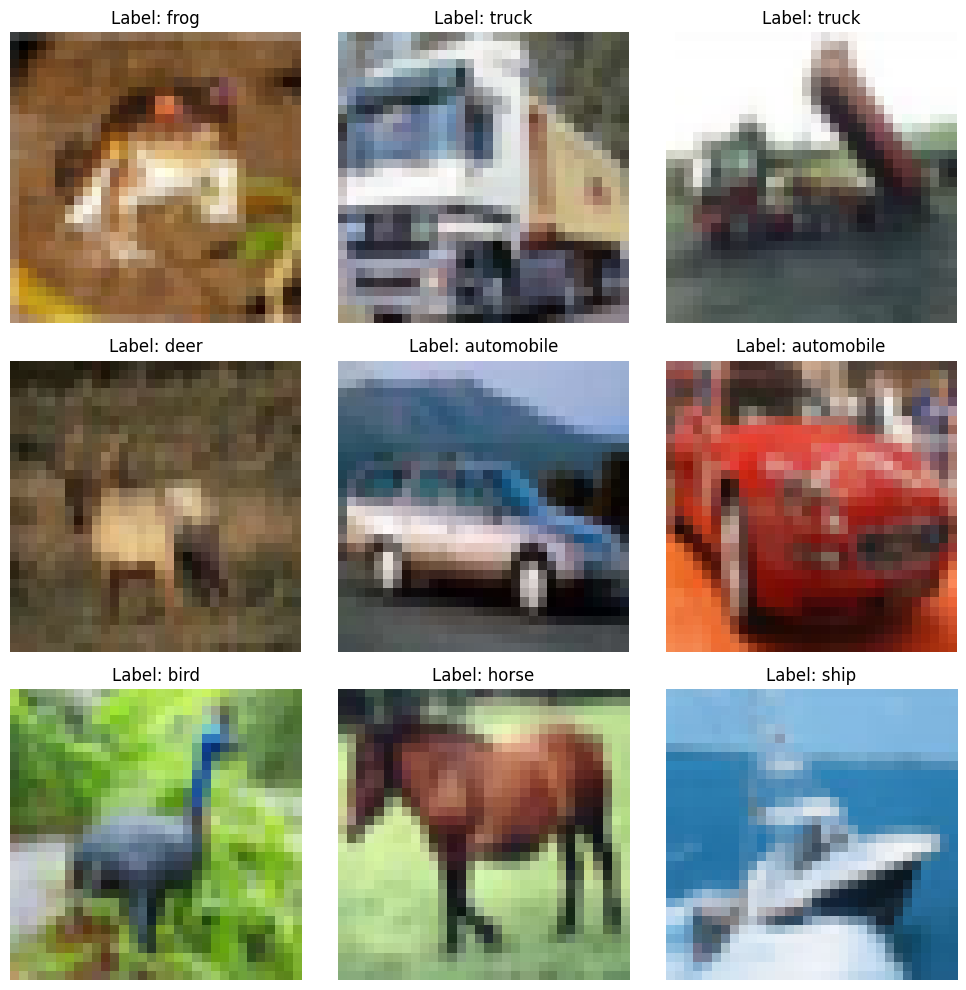


Class Distribution:
airplane: 5000 images
automobile: 5000 images
bird: 5000 images
cat: 5000 images
deer: 5000 images
dog: 5000 images
frog: 5000 images
horse: 5000 images
ship: 5000 images
truck: 5000 images


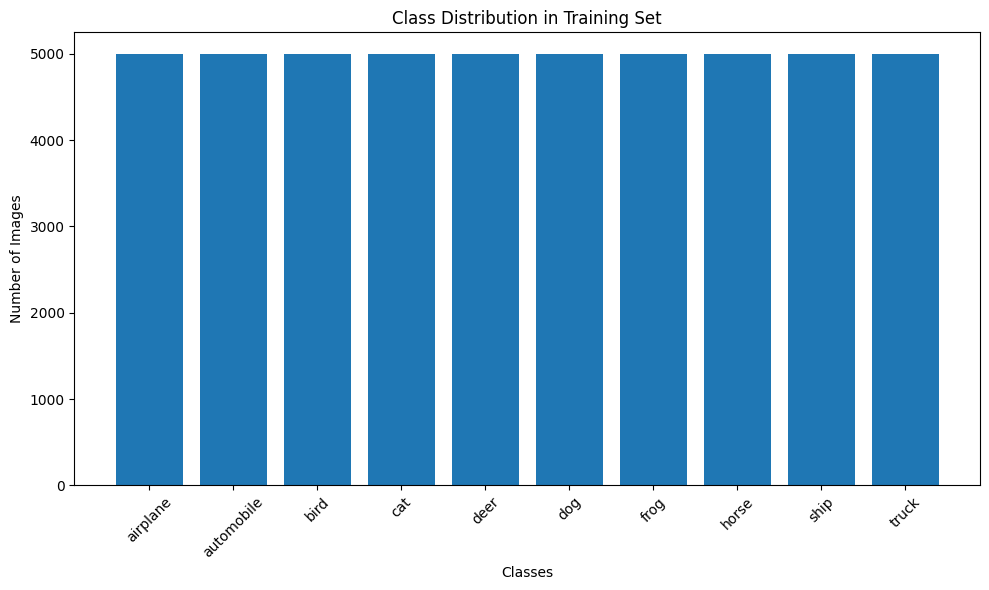

In [5]:
# Only visualize if using real data
if using_real_data:
    # Display a 3x3 grid of sample images
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(x_train[i])
        plt.title(f'Label: {class_names[y_train[i][0] if y_train.ndim > 1 else y_train[i]]}')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig('outputs/plots/sample_images.png')
    plt.show()

# Check class distribution
unique, counts = np.unique(y_train, return_counts=True)
print("\nClass Distribution:")
for i in range(len(unique)):
    print(f"{class_names[unique[i]]}: {counts[i]} images")

# Plot class distribution
plt.figure(figsize=(10, 6))
plt.bar(class_names, [counts[i] for i in range(len(class_names))])
plt.title('Class Distribution in Training Set')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/plots/class_distribution.png')
plt.show()

# 4. Data Preprocessing

In [6]:
# Normalize pixel values to [0, 1] if using real data
if using_real_data:
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0

# One-hot encode labels
if y_train.ndim == 1:
    y_train_onehot = to_categorical(y_train, num_classes=10)
    y_test_onehot = to_categorical(y_test, num_classes=10)
else:
    y_train_onehot = to_categorical(y_train, num_classes=10)
    y_test_onehot = to_categorical(y_test, num_classes=10)

# Split training data into train and validation (80% train, 20% validation)
from sklearn.model_selection import train_test_split

x_train_split, x_val, y_train_split, y_val = train_test_split(
    x_train, y_train_onehot, test_size=0.2, random_state=42, stratify=y_train
)

print(f"\nData Split:")
print(f"Training set: {x_train_split.shape}")
print(f"Validation set: {x_val.shape}")
print(f"Test set: {x_test.shape}")



Data Split:
Training set: (40000, 32, 32, 3)
Validation set: (10000, 32, 32, 3)
Test set: (10000, 32, 32, 3)


# 5. Build CNN Architecture from Scratch

In [8]:
def build_cnn(input_shape=(32, 32, 3), num_classes=10):
    """
    Build a CNN with 3 convolutional blocks
    Architecture: Conv2D → BatchNorm → ReLU → MaxPooling (repeated 3 times)
    Then: Flatten → Dense → Dropout → Output
    """
    model = keras.Sequential([
        # Block 1: 32 filters
        layers.Conv2D(32, kernel_size=(3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Block 2: 64 filters
        layers.Conv2D(64, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Block 3: 128 filters
        layers.Conv2D(128, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Build the model
cnn_model = build_cnn()

# Display model architecture
cnn_model.summary()

# Save model summary to file
with open('outputs/logs/model_summary.txt', 'w', encoding='utf-8') as f:
    cnn_model.summary(print_fn=lambda x: f.write(x + '\n'))


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

# 6. Compile the Model

In [9]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 7. Set Up Callbacks

In [10]:
# 1. EarlyStopping - Stop when validation loss stops improving
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# 2. ModelCheckpoint - Save the best model
model_checkpoint = ModelCheckpoint(
    'outputs/models/best_cnn_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# 3. ReduceLROnPlateau - Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Combine all callbacks
callbacks = [
    early_stopping,
    model_checkpoint,
    reduce_lr
]

print("Callbacks configured successfully!")


Callbacks configured successfully!


# 8. Train the Model

In [11]:
# Record start time
start_time = datetime.datetime.now()
print(f"Training started at: {start_time}")

# Train the model
history = cnn_model.fit(
    x_train_split, y_train_split,
    batch_size=64,
    epochs=30,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    verbose=1
)

# Record end time
end_time = datetime.datetime.now()
training_duration = end_time - start_time
print(f"\nTraining completed at: {end_time}")
print(f"Training duration: {training_duration}")


Training started at: 2026-07-25 22:22:33.283039
Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.3384 - loss: 1.8981
Epoch 1: val_accuracy improved from None to 0.46890, saving model to outputs/models/best_cnn_model.keras

Epoch 1: finished saving model to outputs/models/best_cnn_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 92s 129ms/step - accuracy: 0.4031 - loss: 1.6561 - val_accuracy: 0.4689 - val_loss: 1.4760 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.5101 - loss: 1.3533
Epoch 2: val_accuracy did not improve from 0.46890
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 127ms/step - accuracy: 0.5325 - loss: 1.2944 - val_accuracy: 0.4435 - val_loss: 1.7492 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.5788 - loss: 1.1743
Epoch 3: val_accuracy improved from 0.46890 to 0.64970, saving model to outputs/models/best_cnn_model.keras

Epoch 3: finished saving model to outputs/models/best_cnn_model.

# 9. Plot Training Curves


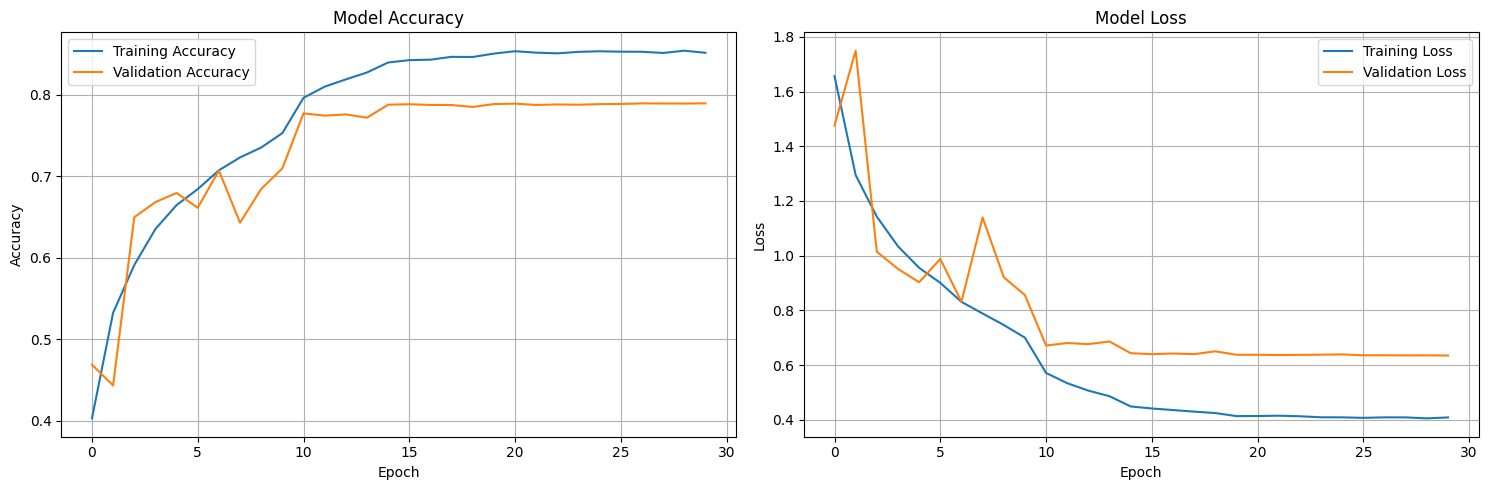


Final Training Accuracy: 0.8514
Final Validation Accuracy: 0.7894
Final Training Loss: 0.4083
Final Validation Loss: 0.6348


In [12]:
def plot_training_curves(history):
    """Plot training and validation accuracy and loss curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy plot
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Loss plot
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('outputs/plots/training_curves.png')
    plt.show()
    
    # Print final metrics
    if history.history['accuracy']:
        final_train_acc = history.history['accuracy'][-1]
        final_val_acc = history.history['val_accuracy'][-1]
        final_train_loss = history.history['loss'][-1]
        final_val_loss = history.history['val_loss'][-1]
        
        print(f"\nFinal Training Accuracy: {final_train_acc:.4f}")
        print(f"Final Validation Accuracy: {final_val_acc:.4f}")
        print(f"Final Training Loss: {final_train_loss:.4f}")
        print(f"Final Validation Loss: {final_val_loss:.4f}")

plot_training_curves(history)


# 10. Evaluate on Test Set


In [13]:
# Load the best model
try:
    best_model = keras.models.load_model('outputs/models/best_cnn_model.keras')
    print("Loaded best model successfully!")
except:
    best_model = cnn_model
    print("Using current model (best model not found)")

# Evaluate on test set
test_loss, test_accuracy = best_model.evaluate(x_test, y_test_onehot, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions
y_pred_proba = best_model.predict(x_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test_onehot, axis=1)


Loaded best model successfully!

Test Loss: 0.6582
Test Accuracy: 0.7819
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


# 11. Classification Report

In [14]:
# Generate classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Save classification report to file
with open('outputs/logs/classification_report.txt', 'w') as f:
    f.write(classification_report(y_true, y_pred, target_names=class_names))



Classification Report:
              precision    recall  f1-score   support

    airplane       0.79      0.82      0.80      1000
  automobile       0.89      0.89      0.89      1000
        bird       0.71      0.69      0.70      1000
         cat       0.61      0.59      0.60      1000
        deer       0.76      0.76      0.76      1000
         dog       0.67      0.68      0.67      1000
        frog       0.83      0.84      0.84      1000
       horse       0.83      0.82      0.83      1000
        ship       0.87      0.87      0.87      1000
       truck       0.86      0.86      0.86      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.78     10000
weighted avg       0.78      0.78      0.78     10000



# 12. Confusion Matrix

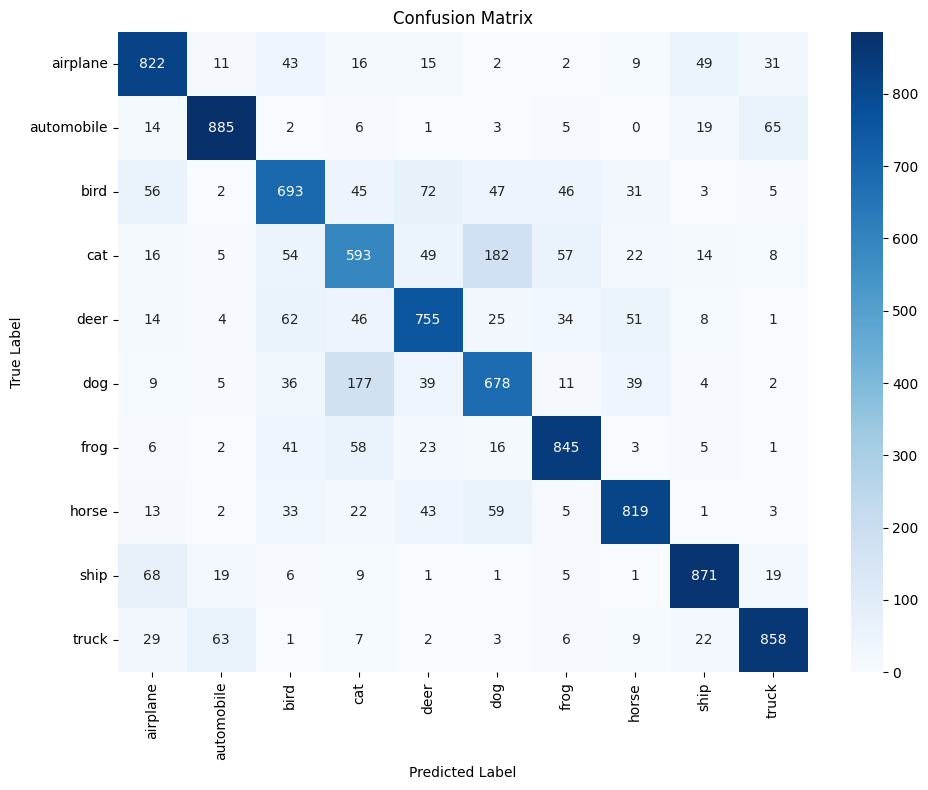


Most confused classes: cat ↔ dog
Confusion rate: 18.20%


In [15]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('outputs/plots/confusion_matrix.png')
plt.show()

# Find most confused pairs
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
np.fill_diagonal(cm_norm, 0)
most_confused = np.unravel_index(np.argmax(cm_norm), cm_norm.shape)
print(f"\nMost confused classes: {class_names[most_confused[0]]} ↔ {class_names[most_confused[1]]}")
print(f"Confusion rate: {cm_norm[most_confused]:.2%}")


# 13. Misclassified Images Grid

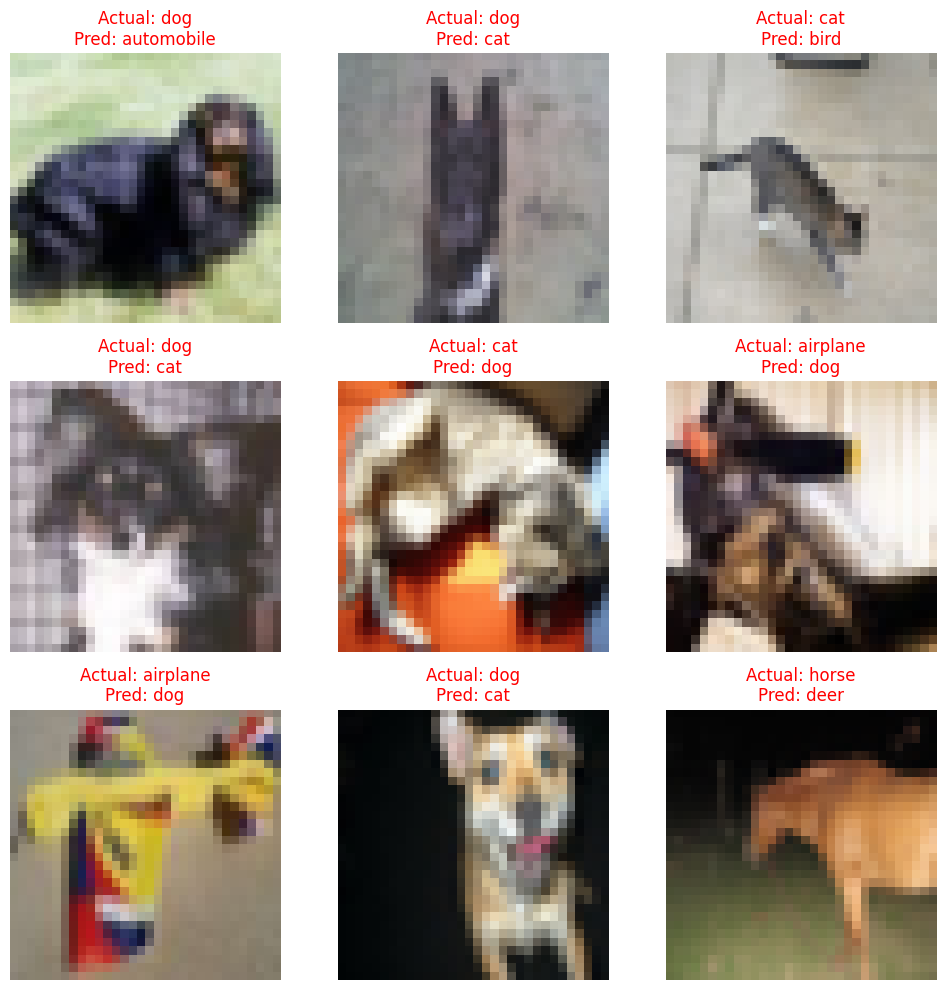

In [16]:
def plot_misclassified_grid(x_test, y_true, y_pred, class_names, grid_size=3):
    """Display a grid of misclassified images with actual and predicted labels."""
    # Find misclassified indices
    misclassified_idx = np.where(y_pred != y_true)[0]
    
    if len(misclassified_idx) < grid_size * grid_size:
        print(f"Only {len(misclassified_idx)} misclassified images found. Displaying all.")
        grid_size = int(np.ceil(np.sqrt(len(misclassified_idx))))
    
    # Randomly select misclassified images for display
    np.random.seed(42)
    num_samples = min(grid_size * grid_size, len(misclassified_idx))
    selected_idx = np.random.choice(misclassified_idx, size=num_samples, replace=False) if len(misclassified_idx) > 0 else []
    
    if len(selected_idx) == 0:
        print("No misclassified images to display!")
        return
    
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    axes = axes.flatten()
    
    for i, idx in enumerate(selected_idx):
        axes[i].imshow(x_test[idx])
        axes[i].set_title(f'Actual: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}', 
                         color='red' if y_pred[idx] != y_true[idx] else 'green')
        axes[i].axis('off')
    
    # Hide empty subplots
    for i in range(len(selected_idx), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('outputs/plots/misclassified_grid.png')
    plt.show()

if using_real_data:
    plot_misclassified_grid(x_test, y_true, y_pred, class_names)


# 14. Per-Class Accuracy

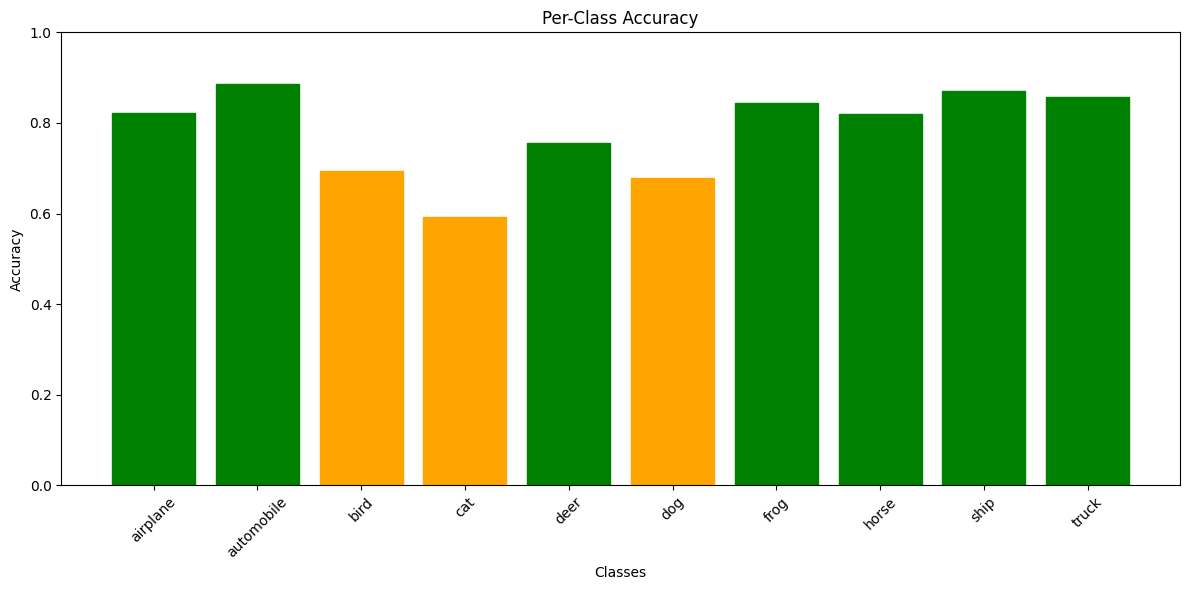


Per-Class Accuracy:
airplane: 82.20%
automobile: 88.50%
bird: 69.30%
cat: 59.30%
deer: 75.50%
dog: 67.80%
frog: 84.50%
horse: 81.90%
ship: 87.10%
truck: 85.80%


In [17]:
# Calculate per-class accuracy
per_class_accuracy = []
for i in range(10):
    class_idx = np.where(y_true == i)[0]
    if len(class_idx) > 0:
        class_correct = np.sum(y_pred[class_idx] == i)
        class_total = len(class_idx)
        per_class_accuracy.append(class_correct / class_total)
    else:
        per_class_accuracy.append(0.0)

# Plot per-class accuracy
plt.figure(figsize=(12, 6))
bars = plt.bar(class_names, per_class_accuracy)
plt.title('Per-Class Accuracy')
plt.xlabel('Classes')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Color bars based on accuracy
for bar, acc in zip(bars, per_class_accuracy):
    if acc < 0.5:
        bar.set_color('red')
    elif acc < 0.7:
        bar.set_color('orange')
    else:
        bar.set_color('green')

plt.tight_layout()
plt.savefig('outputs/plots/per_class_accuracy.png')
plt.show()

# Print per-class accuracy
print("\nPer-Class Accuracy:")
for i, acc in enumerate(per_class_accuracy):
    print(f"{class_names[i]}: {acc:.2%}")


# 15. Summary and Reflection

In [18]:
# Print final summary
print("\n" + "="*60)
print("DAY 28 SUMMARY: CNN Architecture on CIFAR-10")
print("="*60)
print(f"Dataset: {'Real CIFAR-10' if using_real_data else 'Synthetic Data'}")
print(f"Best Model Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Training Duration: {training_duration}")
print(f"Model Parameters: {cnn_model.count_params():,}")

if using_real_data:
    print("\nBest Performing Classes:")
    for i, acc in enumerate(per_class_accuracy):
        if acc >= 0.70:
            print(f"  - {class_names[i]}: {acc:.2%}")
    print("\nMost Challenging Classes:")
    for i, acc in enumerate(per_class_accuracy):
        if acc < 0.60:
            print(f"  - {class_names[i]}: {acc:.2%}")
    if most_confused:
        print(f"\nMost Confused Pair: {class_names[most_confused[0]]} ↔ {class_names[most_confused[1]]}")

print("\nFiles Generated:")
print("  - outputs/models/best_cnn_model.keras")
print("  - outputs/plots/training_curves.png")
print("  - outputs/plots/confusion_matrix.png")
print("  - outputs/plots/misclassified_grid.png")
print("  - outputs/plots/per_class_accuracy.png")
print("  - outputs/plots/class_distribution.png")
print("  - outputs/logs/classification_report.txt")
print("="*60)


DAY 28 SUMMARY: CNN Architecture on CIFAR-10
Dataset: Real CIFAR-10
Best Model Test Accuracy: 0.7819 (78.19%)
Training Duration: 0:46:26.898670
Model Parameters: 621,258

Best Performing Classes:
  - airplane: 82.20%
  - automobile: 88.50%
  - deer: 75.50%
  - frog: 84.50%
  - horse: 81.90%
  - ship: 87.10%
  - truck: 85.80%

Most Challenging Classes:
  - cat: 59.30%

Most Confused Pair: cat ↔ dog

Files Generated:
  - outputs/models/best_cnn_model.keras
  - outputs/plots/training_curves.png
  - outputs/plots/confusion_matrix.png
  - outputs/plots/misclassified_grid.png
  - outputs/plots/per_class_accuracy.png
  - outputs/plots/class_distribution.png
  - outputs/logs/classification_report.txt


# 16. Reflection: CNN vs ANN

reflection = """
# Why CNN Learns Image Features More Effectively Than Standard ANN

## Key Reasons:

### 1. Spatial Hierarchy
CNNs preserve spatial relationships between pixels through their convolutional structure. 
Instead of treating each pixel independently (like an ANN would), CNNs consider local 
neighbourhoods (using kernels/filters) to detect patterns like edges, textures, and 
shapes.

### 2. Parameter Efficiency
CNNs use weight sharing - the same filter is applied across the entire image. This 
drastically reduces the number of parameters compared to a fully connected ANN. For 
a 32x32x3 image, an ANN would need 3072 input neurons with millions of connections, 
while a CNN uses a much smaller set of learnable filters.

### 3. Translation Invariance
Through the combination of convolution and max-pooling, CNNs become robust to small 
shifts, rotations, and distortions in the image. Max-pooling selects the maximum 
value in a region, making the detection less sensitive to exact location.

### 4. Hierarchical Feature Learning
Early layers detect simple patterns (edges, color blobs), middle layers combine these 
into more complex patterns (shapes, textures), and deeper layers learn object parts 
and full objects. This hierarchical learning mirrors how the human visual system 
works.

## Layer Contributions:

- **Conv2D**: Learns spatial patterns using learnable filters that slide across the 
  image. Each filter detects a specific pattern.

- **MaxPooling**: Reduces spatial dimensions, provides translation invariance, and 
  reduces computational load.

- **BatchNormalization**: Normalizes layer outputs, speeds up training, and provides 
  mild regularization.

- **Flatten**: Converts 2D feature maps into a 1D vector for the Dense layers.

- **Dense**: Performs the final classification based on the extracted features.

- **Dropout**: Regularization technique that prevents overfitting by randomly 
  dropping neurons during training.

## Conclusion:
CNNs are superior for image tasks because they're explicitly designed to exploit the 
spatial structure of images. ANNs, while powerful for tabular data, treat images as 
flat vectors and miss the crucial spatial relationships that define visual content.
"""